25 numeric features


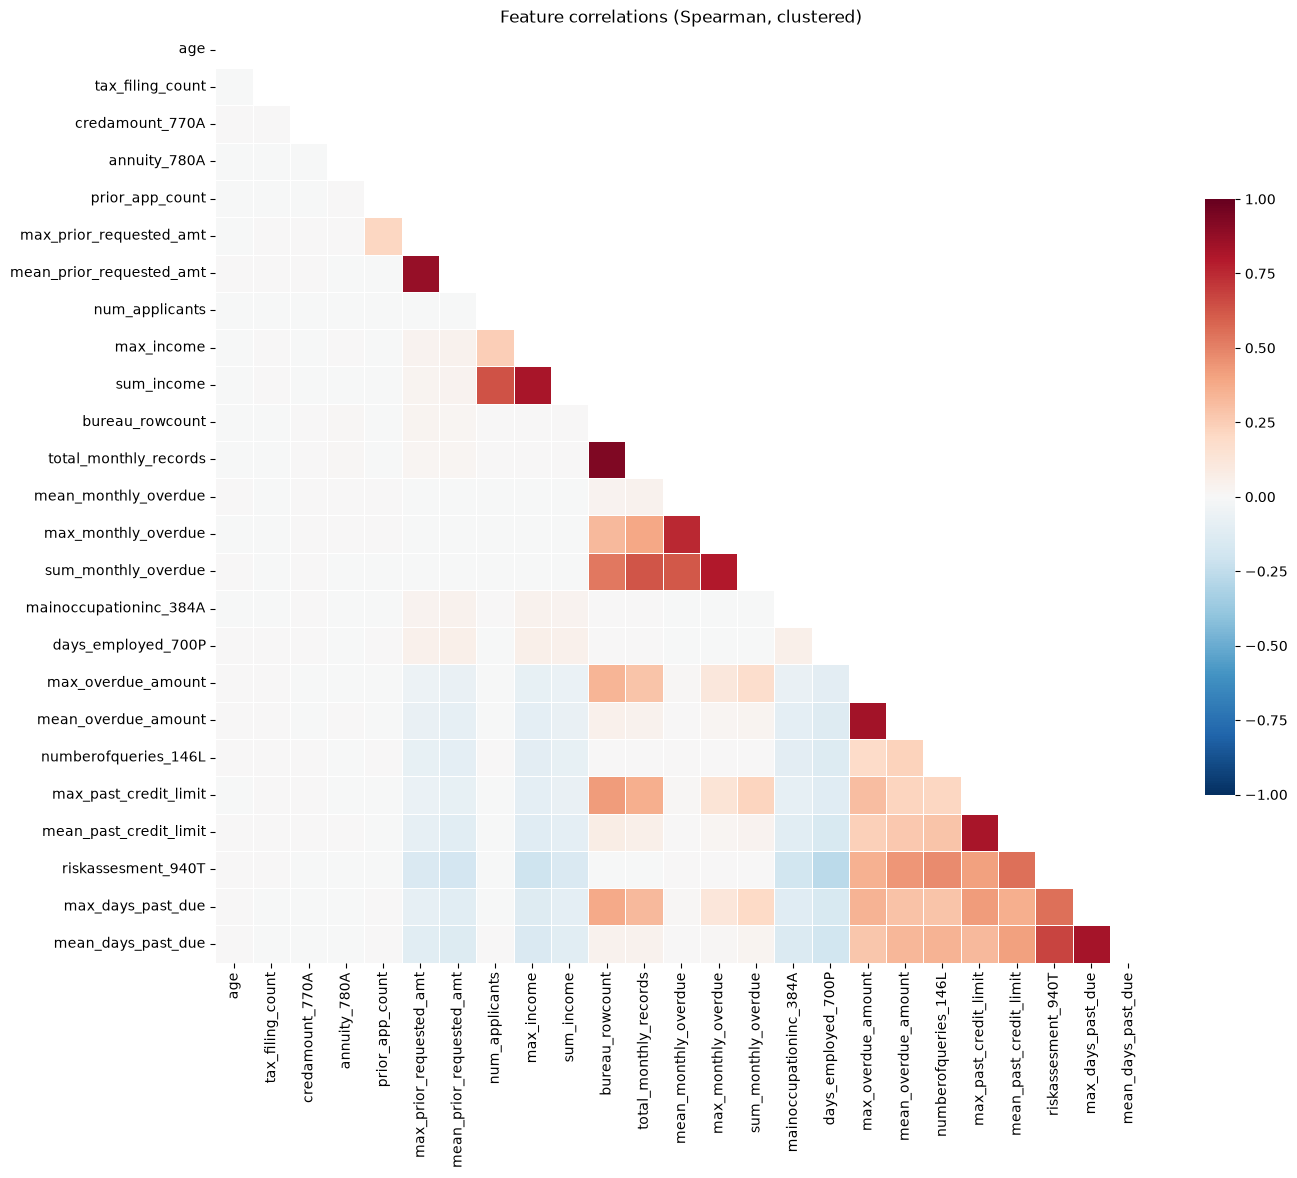

In [8]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

df = pd.read_parquet("../data/master.parquet")

# is_thin_file never co-occurs with bureau cols -> undefined pairs
# drop is_thin_file
drop = ["case_id", "MONTH", "WEEK_NUM", "target", "is_thin_file"]
num = df.select_dtypes("number").columns.difference(drop).tolist()
print(len(num), "numeric features")

# spearman: resistant to skewed money columns
c = df[num].corr(method="spearman")

# check - linkage fails on any NaN
assert not c.isna().any().any(), c.columns[c.isna().any()].tolist()

# |rho| -> distance, so similar features cluster
d = squareform(1 - c.abs().values, checks=False)
order = hierarchy.leaves_list(hierarchy.linkage(d, "average"))
c = c.iloc[order, order]

# read each pair once
mask = np.triu(np.ones_like(c, dtype=bool))
plt.figure(figsize=(14, 12))

# center=0 + fixed vmin/vmax: colors mean the same across runs
sns.heatmap(c, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.6})
plt.title("Feature correlations (Spearman, clustered)")
plt.tight_layout()